# Chapter 12 — Costs, Slippage, and Capacity

The Ch8→Ch11 deflation arc closed with **walk-forward OOS Sharpe of +0.88, 95% CI ≈ (−1.6, +3.5)** — positive point estimate, CI straddling zero. Every Sharpe in that arc was a *zero-cost* number. Ch12 stacks the frictions a real broker imposes: bid/ask spread, commission per trade, and slippage (market impact). The chapter answers the next question: **does the strategy survive realistic execution?**

The strategy's per-trade mean PnL on the Ch11 ledger is about **0.2-0.5 bp**, with per-trade std ~7 bp. A 1 bp round-trip cost is several times the per-trade mean. The cost wedge is *not* a small correction.

Three flavors of cost:

1. **Explicit cost** — what hits your statement. Commission, exchange/SEC fees, financing on overnight. Visible, billed, easy to model.
2. **Implicit cost** — what you pay through prices. Bid/ask spread (you cross it on entry and exit), and slippage (your size pushes the next print). Invisible on the statement; first-order on small-edge strategies.
3. **Capacity** — the size beyond which your own slippage eats the edge. Defined by setting expected slippage equal to per-trade mean PnL.

This chapter measures all three on QQQ 1-min data, then re-runs Ch11's threshold sweep with after-cost Sharpe as the objective.


## §1 — The setup: Ch11's OOS ledger meets reality

Per-trade statistics from Ch11's walk-forward OOS ledger (575 trades over 148 sessions):

- mean ≈ **0.16 bp**
- std ≈ **7.4 bp**
- pre-cost annualized Sharpe: **+0.88** with 95% CI ≈ (−1.6, +3.5)

The cost budget per trade is whatever fraction of 0.16 bp we can spend without making the after-cost expectancy negative. That budget is *tiny*. The question of this chapter is whether even the cheapest possible execution path — large account at a zero-commission broker, posting limit orders, trading small size — stays under that budget.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE = Path("../06-bridge-to-intraday/data")
qqq = pd.read_parquet(CACHE / "qqq_1min.parquet")
qqq.index = pd.to_datetime(qqq.index, utc=True).tz_convert("America/New_York")
qqq["minute_of_day"] = qqq.index.hour * 60 + qqq.index.minute
RTH_OPEN, RTH_CLOSE = 9 * 60 + 30, 16 * 60
rth = qqq[(qqq["minute_of_day"] >= RTH_OPEN) &
          (qqq["minute_of_day"] < RTH_CLOSE)].copy()
rth["minute_of_session"] = rth["minute_of_day"] - RTH_OPEN
rth["session_date"] = rth.index.normalize()
# 1-min log returns; null the first bar of each session so we don't carry
# returns across the overnight gap.
rth["log_ret"] = np.log(rth["close"] / rth["close"].shift(1))
first_bars = rth.groupby("session_date").head(1).index
rth.loc[first_bars, "log_ret"] = np.nan
print(f"QQQ RTH bars: {len(rth):,} over {rth['session_date'].nunique()} sessions")


QQQ RTH bars: 95,318 over 251 sessions


## §2 — Effective spread without a quote feed: Roll's estimator

The bid/ask spread on QQQ is the cleanest first-order cost. On free retail data feeds (Alpaca's IEX feed, Yahoo, Polygon-free), you only get trade prints — no quote-by-quote bid/ask. We need an estimator that recovers the *effective* spread from trades alone.

**Roll's (1984) estimator.** If trades bounce randomly between bid and ask but the *true* (mid) price follows a random walk, then consecutive trade returns have a mechanical negative autocovariance: a trade at the ask followed by a trade at the bid produces a negative return that does not reflect any change in fair value. The expected lag-1 autocovariance of trade-return is **−s²**, where *s* is the half-spread.

> **Formula — Roll's effective half-spread.**
>
> s = √(−Cov(r<sub>t</sub>, r<sub>t−1</sub>)) when the lag-1 covariance is negative
>
> where:
> - *r<sub>t</sub>* = log return between consecutive trade prices (here, 1-min closes treated as trade prints)
> - Cov is the sample autocovariance at lag 1
> - *s* is in the same units as *r* (here, fraction of price; multiply by 1e4 for bp)
>
> If the lag-1 covariance is *positive*, Roll's is undefined — typically because real momentum or mean-reversion is contaminating the bid-ask bounce signal.

**The Ch7 connection — and the chapter's reframing.** Roll's estimator and Ch7's lag-1 ρ are the *same number*, just rescaled. Ch7 measured QQQ all-RTH lag-1 ρ = −0.028. If you divide the lag-1 covariance into bid-ask-bounce mechanical noise and real-economic mean-reversion, Roll's gives you the noise component. **Anything left over is the genuine signal Ch7's strategy is harvesting** — but Roll's gives an *upper bound* on the spread because some of that lag-1 ρ may be real mean-reversion miscounted as spread.

In [2]:
def roll_half_spread(ret_series):
    r = ret_series.dropna().to_numpy()
    if len(r) < 2:
        return np.nan, np.nan
    cov1 = np.cov(r[1:], r[:-1])[0, 1]
    s = np.sqrt(-cov1) if cov1 < 0 else np.nan
    return s, cov1

# All-RTH
s_all, cov_all = roll_half_spread(rth["log_ret"])
# Ch7's MR-strongest window: closing 30 minutes
close_win = rth[(rth["minute_of_session"] >= 360) &
                (rth["minute_of_session"] < 390)]
s_close, cov_close = roll_half_spread(close_win["log_ret"])
# Midday
mid = rth[(rth["minute_of_session"] >= 60) &
          (rth["minute_of_session"] < 300)]
s_mid, cov_mid = roll_half_spread(mid["log_ret"])

print(f"Roll's half-spread (all RTH):       {s_all*1e4:.3f} bp")
print(f"Roll's half-spread (closing 30min): {s_close*1e4:.3f} bp")
print(f"Roll's half-spread (midday):        {s_mid*1e4:.3f} bp")


Roll's half-spread (all RTH):       0.724 bp
Roll's half-spread (closing 30min): 0.538 bp
Roll's half-spread (midday):        0.713 bp


**Three numbers worth comparing.** All-RTH **0.72 bp**; closing-window **0.54 bp**; midday **0.71 bp**.

The headline finding is the closing window's *lower* half-spread, not higher. Ch7 found the closing 30 min to be the *strongest* mean-reversion window (lag-1 ρ = −0.067, ~2× midday); we'd expect that stronger ρ to translate into a *larger* Roll's number — Roll's mechanically scales with |ρ|. The fact that closing's Roll's is *lower* than all-RTH means closing's larger lag-1 ρ is almost entirely *real* mean-reversion, not bid-ask-bounce noise. **The closing window is both higher-edge AND lower-cost.** It is the least hostile window from a cost-economics standpoint.

This also flags a methodology note: Roll's is an **upper bound** on the true effective spread because it cannot tell genuine mean-reversion apart from bid-ask noise. The Corwin-Schultz estimator below gives an independent second opinion.

### Second opinion: the Corwin-Schultz (2012) estimator

Corwin-Schultz extracts the spread from the high–low *range* of two consecutive bars. The intuition: over a short window, the high is more likely a buyer-initiated print (near the ask) and the low a seller-initiated print (near the bid). The expected log(H/L) inflates by approximately the spread on top of true volatility. Subtracting the variance contribution (calibrated from a two-bar window) leaves the spread.

> **Formula — Corwin-Schultz spread (one bar).**
>
> β = (log(H<sub>t</sub>/L<sub>t</sub>))² + (log(H<sub>t+1</sub>/L<sub>t+1</sub>))²
> γ = (log(max(H<sub>t</sub>, H<sub>t+1</sub>) / min(L<sub>t</sub>, L<sub>t+1</sub>)))²
> α = (√(2β) − √β) / (3 − 2√2) − √(γ / (3 − 2√2))
> spread = 2 (e<sup>α</sup> − 1) / (1 + e<sup>α</sup>)
>
> where:
> - *H<sub>t</sub>*, *L<sub>t</sub>* are the high and low of bar *t* (price units)
> - *β* and *γ* are sums of squared log ranges (unitless); β uses single-bar ranges, γ uses the two-bar combined range
> - the constants 3 − 2√2 ≈ 0.172 normalize for the variance of a Brownian high–low under continuous trading
> - *spread* is the full bid/ask spread as a fraction of price; divide by 2 for half-spread; multiply by 1e4 for bp

The estimator was published for daily data and is being **adapted to 1-min bars** here. Adaptation caveat: the underlying H/L-from-Brownian-motion derivation assumes continuous trading within the bar; 1-min bars are short enough that this approximation degrades on thinly-traded names. For a liquid ETF like QQQ at 1-min, prior empirical work finds Corwin-Schultz tracks consolidated spreads within a few tens of bp.

In [3]:
# Two-bar Corwin-Schultz on consecutive 1-min bars.
H = rth["high"].values
L = rth["low"].values
# Bar-pairs: (t, t+1)
beta = (np.log(H[:-1] / L[:-1])) ** 2 + (np.log(H[1:] / L[1:])) ** 2
H2 = np.maximum(H[:-1], H[1:])
L2 = np.minimum(L[:-1], L[1:])
gamma = (np.log(H2 / L2)) ** 2
sqrt2 = np.sqrt(2)
alpha = ((np.sqrt(2 * beta) - np.sqrt(beta)) / (3 - 2 * sqrt2)
         - np.sqrt(gamma / (3 - 2 * sqrt2)))
# Full spread, then drop bars with negative/NaN alpha (econometric noise floor).
cs_full = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))
cs_full = cs_full[np.isfinite(cs_full) & (cs_full > 0)]
cs_half = cs_full.mean() / 2
print(f"Corwin-Schultz half-spread: {cs_half*1e4:.3f} bp  "
      f"(n={len(cs_full):,} valid bar-pairs)")
print(f"Roll's all-RTH half-spread: {s_all*1e4:.3f} bp  (for comparison)")


Corwin-Schultz half-spread: 0.794 bp  (n=37,383 valid bar-pairs)
Roll's all-RTH half-spread: 0.724 bp  (for comparison)


**Corwin-Schultz 0.79 bp ≈ Roll's 0.72 bp** — agreement within 10%. Two estimators built on independent assumptions (Roll's: bid-ask bounce in trade prices; CS: H/L range relative to variance) land on the same order of magnitude.

We will use **half-spread = 0.72 bp** (Roll's all-RTH) as the chapter's working number. The closing-window 0.54 bp is the *cheapest* execution window but only applies to Ch7's specific signal window; we want a number that bounds the round-trip cost across the entire trading day.

## §3 — Explicit cost: commission

Commission is the most predictable cost and the easiest to size against alternatives. Three reference points for retail QQQ execution in 2026:

| Broker | Structure | Per-share | $30k notional (~43 sh) | bp on $30k |
|---|---|---|---|---|
| Schwab, Fidelity, Robinhood | Zero (via PFOF) | $0 | $0.00 | **0.000** |
| IBKR tiered | Per-share | $0.0035-$0.005 | $0.15-$0.22 | **0.05-0.07** |
| IBKR fixed | Min $1 / order | $0.005 capped | $1.00 | **0.33** |

> **Definition — payment for order flow (PFOF).** A retail broker routes the customer's order to a wholesale market maker (Citadel, Virtu) instead of the public lit exchange. The market maker pays the broker a fraction of a cent per share for the order flow; the customer gets price improvement vs the National Best Bid and Offer (NBBO) — typically 0.01-0.04 bp on a $30k QQQ trade — but doesn't see whether the improvement covers what the broker received. Operationally PFOF makes "zero commission" possible; it shifts the cost into the spread the wholesale market maker captures.

The right reference for an honest cost model is **IBKR tiered at $0.005/share ≈ 0.07 bp per leg** — large enough to be a realistic worst case for someone who is *not* on PFOF.

In [4]:
qqq_px = float(rth["close"].iloc[-1])
ibkr_per_share = 0.005  # $/share, tiered
trade_dollars = 30_000  # representative position size
trade_shares = trade_dollars / qqq_px
commission_dollars = trade_shares * ibkr_per_share
# bp on the notional (per leg)
commission_bp = commission_dollars / trade_dollars * 1e4
print(f"Reference QQQ price:       ${qqq_px:.2f}")
print(f"$30k position size:        {trade_shares:.2f} shares")
print(f"IBKR tiered commission:    ${commission_dollars:.3f}  "
      f"({commission_bp:.3f} bp per leg)")
print(f"Zero-commission broker:    $0.000  (0.000 bp per leg)")


Reference QQQ price:       $694.93
$30k position size:        43.17 shares
IBKR tiered commission:    $0.216  (0.072 bp per leg)
Zero-commission broker:    $0.000  (0.000 bp per leg)


## §4 — Implicit cost: slippage and the square-root impact law

When your buy order is large relative to the resting size on the offer, you walk up the book — first share fills at the inside ask, next at the next price level, etc. The *executed* average is worse than the inside ask by an amount that scales with order size. This is **market impact**.

The empirical regularity, robust across markets and decades of TAQ studies: temporary impact scales with the **square root** of the order's fraction of average daily volume.

> **Formula — square-root impact law (per leg).**
>
> impact = η · σ<sub>d</sub> · √(Q / ADV)
>
> where:
> - *η* is the **impact coefficient**, empirically ≈ 0.1 for liquid US equities (Almgren et al. 2005); 0.3 is conservative; 0.5 is illiquid-microcap territory
> - *σ<sub>d</sub>* is **daily volatility** of the underlying (fraction; e.g., 0.01 for 1%)
> - *Q* is the order's dollar size (USD)
> - *ADV* is **average daily dollar volume** of the underlying (USD)
> - *impact* is in the same units as σ<sub>d</sub> (fraction); multiply by 1e4 for bp
>
> Multiply by 2 for a round-trip (entry + exit).

**Why square root?** Two informal intuitions. (1) Above some "good" size, you have to wait or be patient for liquidity to refresh; doubling the size doesn't double the impact because liquidity arrives stochastically and partially fills you at the inside. (2) From a model-portfolio perspective, dealer inventory risk scales with √variance, so dealers price impact accordingly.

In [5]:
# QQQ daily statistics
daily = rth.groupby("session_date").agg(
    close=("close", "last"),
    vol=("volume", "sum"),
)
daily["ret"] = np.log(daily["close"] / daily["close"].shift(1))
sigma_d = daily["ret"].std()
# ADV from IEX feed (small fraction of consolidated tape — see §4.1 below)
adv_shares_iex = daily["vol"].mean()
adv_dollars_iex = adv_shares_iex * daily["close"].mean()
# Realistic consolidated-tape ADV for QQQ in 2025-2026
adv_dollars_consolidated = 15e9
print(f"QQQ daily sigma:               {sigma_d:.4f}  ({sigma_d*100:.2f}%)")
print(f"QQQ ADV (IEX feed):            ${adv_dollars_iex/1e9:.2f}B")
print(f"QQQ ADV (consolidated, est.):  ${adv_dollars_consolidated/1e9:.2f}B")


QQQ daily sigma:               0.0102  (1.02%)
QQQ ADV (IEX feed):            $0.44B
QQQ ADV (consolidated, est.):  $15.00B


### §4.1 — Data caveat: IEX vs consolidated ADV

Alpaca's free tier provides the **IEX feed only** — about 2-3% of consolidated US equities volume. The ADV we computed from `daily["volume"].sum()` is ~$0.44B; the actual consolidated-tape ADV for QQQ is ~$15B. The impact equation uses the *full liquidity pool* the order will access, so we use the **consolidated ADV of $15B** as the denominator. The IEX number is what the chapter's data shows; the consolidated number is what reality is.

(The chapter's verdict turns out to be robust to this choice — see §6.)

In [6]:
def impact_bp(Q_dollars, eta=0.1, sigma_d=sigma_d, adv=adv_dollars_consolidated):
    return eta * sigma_d * np.sqrt(Q_dollars / adv) * 1e4

print("Per-leg impact on QQQ (consolidated ADV $15B):")
print(f"{'Q':>14}  {'eta=0.1':>10}  {'eta=0.3':>10}")
for Q in [10_000, 30_000, 100_000, 1_000_000, 10_000_000]:
    print(f"  ${Q:>10,}  {impact_bp(Q):>8.3f} bp  "
          f"{impact_bp(Q, eta=0.3):>8.3f} bp")


Per-leg impact on QQQ (consolidated ADV $15B):
             Q     eta=0.1     eta=0.3
  $    10,000     0.008 bp     0.025 bp
  $    30,000     0.014 bp     0.043 bp
  $   100,000     0.026 bp     0.079 bp
  $ 1,000,000     0.084 bp     0.251 bp
  $10,000,000     0.265 bp     0.794 bp


**Three takeaways.**

1. **At $30k notional, impact is 0.014 bp.** Below the noise floor of every other cost component. A retail-sized trader on QQQ pays ~0 in impact.
2. **At $1M notional, impact is 0.08 bp — still small.** QQQ is liquid enough that even 7-figure orders barely move the inside price.
3. **At $10M, impact reaches 0.26 bp.** Now comparable in magnitude to half-spread (0.72 bp) and well above commission (0.07 bp). This is the size at which slippage starts to dominate the cost stack.

For a retail strategy trading $10k-$100k, **explicit cost + half-spread is ~95% of total cost**. Impact only bites in institutional territory. The strategy's *capacity* (next section) is the size where impact starts to bite enough to erase the per-trade edge.

## §5 — Capacity: where does slippage eat the edge?

Capacity is the answer to: **what's the largest Q I can put in this strategy before my own slippage eats the per-trade expectancy?**

Set expected per-trade PnL minus all costs to zero, solve for Q:

> **Formula — strategy capacity Q\*.**
>
> μ<sub>trade</sub> − 2·s − 2·c − 2·η·σ<sub>d</sub>·√(Q\* / ADV) = 0
>
> ⇒ Q\* = ADV · ((μ<sub>trade</sub> − 2s − 2c) / (2η σ<sub>d</sub>))²
>
> where:
> - *μ<sub>trade</sub>* = pre-cost per-trade mean PnL (bp or fraction; use same units as costs)
> - *s* = half-spread per leg (× 2 for round-trip)
> - *c* = commission per leg (× 2 for round-trip)
> - *η σ<sub>d</sub>* = per-leg impact coefficient (× 2 for round-trip)
> - *Q\** is the *break-even* trade size — at Q\*, the after-cost expectancy is exactly zero
>
> If the **impact budget** (μ<sub>trade</sub> − 2s − 2c) is negative, the strategy is unprofitable at any size — costs eat the edge before impact even enters. Then Q\* = $0.

The capacity equation is what makes "spread + commission" the **fixed cost** of trading and impact the **variable cost** that grows with size. The fixed cost has to be paid out of every per-trade dollar; if the fixed cost alone exceeds μ<sub>trade</sub>, there is no room for size at all.

In [7]:
# We reuse Ch10/Ch11's event-driven backtest: trailing-σ entry,
# fixed-K exit, single position, force-flatten at session end.
N, K = 1, 3  # Ch8's chosen parameters

def event_driven_backtest(rth_df, k_sigma, lookback=20):
    # Build per-session pools of N-bar prior moves inside the closing window
    # (Ch7's MR-strongest gate). Trailing-20-session σ threshold from these
    # pooled prior moves; point-in-time clean.
    trades = []
    priors_by_session = {}
    dates_sorted = sorted(rth_df["session_date"].unique())
    for date in dates_sorted:
        day = rth_df[rth_df["session_date"] == date].sort_index().reset_index()
        pts = []
        for i in range(N, len(day)):
            if 360 <= day.loc[i, "minute_of_session"] < 390 - K:
                pts.append(np.log(day.loc[i, "close"] / day.loc[i - N, "close"]))
        priors_by_session[date] = np.array(pts)
    for date_idx, date in enumerate(dates_sorted):
        if date_idx < lookback:
            continue
        history = np.concatenate(
            [priors_by_session[d] for d in dates_sorted[date_idx - lookback:date_idx]]
        )
        thresh = k_sigma * history.std() if len(history) > 0 else None
        if thresh is None:
            continue
        day = rth_df[rth_df["session_date"] == date].sort_index().reset_index()
        in_pos, entry_i, entry_px = 0, None, None
        for i in range(len(day)):
            mos = day.loc[i, "minute_of_session"]
            # Exit first if K bars have elapsed (next-open fill).
            if in_pos != 0 and (i - entry_i) >= K:
                exit_i = min(i + 1, len(day) - 1)
                exit_px = day.loc[exit_i, "open"]
                trades.append({"date": date,
                               "pnl_log": in_pos * np.log(exit_px / entry_px)})
                in_pos, entry_i, entry_px = 0, None, None
            # Then entry, if signal triggers and we are flat.
            if in_pos == 0 and 360 <= mos < 390 - K and i >= N:
                prior_N = np.log(day.loc[i, "close"] / day.loc[i - N, "close"])
                if abs(prior_N) > thresh:
                    sig = -1 if prior_N > 0 else +1
                    entry_i_next = min(i + 1, len(day) - 1)
                    in_pos = sig
                    entry_i = i
                    entry_px = day.loc[entry_i_next, "open"]
    return pd.DataFrame(trades)


# Run at Ch8's representative k_sigma = 1.0 to recover per-trade stats.
tr_ref = event_driven_backtest(rth, k_sigma=1.0)
mu_trade = tr_ref["pnl_log"].mean()
sigma_trade = tr_ref["pnl_log"].std()
n_trades = len(tr_ref)
print(f"At k_sigma = 1.0:")
print(f"  trades:           {n_trades}")
print(f"  per-trade mean:   {mu_trade*1e4:+.3f} bp")
print(f"  per-trade std:    {sigma_trade*1e4:.3f} bp")


At k_sigma = 1.0:
  trades:           892
  per-trade mean:   +0.317 bp
  per-trade std:    6.902 bp


In [8]:
# Cost stack at $30k representative trade size
half_spread_bp = s_all * 1e4
commission_per_leg_bp = commission_bp
Q_ref = 30_000
impact_per_leg_bp = impact_bp(Q_ref, eta=0.1)
rt_cost_bp = 2 * (half_spread_bp + commission_per_leg_bp + impact_per_leg_bp)
print(f"Round-trip cost @ Q=${Q_ref:,}:")
print(f"  spread:      2 x {half_spread_bp:.3f} = {2*half_spread_bp:.3f} bp")
print(f"  commission:  2 x {commission_per_leg_bp:.3f} = "
      f"{2*commission_per_leg_bp:.3f} bp")
print(f"  impact:      2 x {impact_per_leg_bp:.3f} = "
      f"{2*impact_per_leg_bp:.3f} bp")
print(f"  TOTAL:       {rt_cost_bp:.3f} bp")
print(f"\nPer-trade mean (k=1.0):   {mu_trade*1e4:+.3f} bp")
print(f"After-cost per-trade:     {mu_trade*1e4 - rt_cost_bp:+.3f} bp")


Round-trip cost @ Q=$30,000:
  spread:      2 x 0.724 = 1.448 bp
  commission:  2 x 0.072 = 0.144 bp
  impact:      2 x 0.014 = 0.029 bp
  TOTAL:       1.621 bp

Per-trade mean (k=1.0):   +0.317 bp
After-cost per-trade:     -1.303 bp


**Round-trip cost ≈ 1.62 bp; per-trade mean = 0.32 bp. After-cost per-trade mean = −1.30 bp.**

The strategy loses ~1.3 bp per round-trip on average at k_σ = 1.0. The cost stack alone is 5× the per-trade edge. **The impact budget is negative even at Q = $30k**, the smallest realistic retail trade size. At Q = $0 (no impact, only spread + commission), the budget is still **0.32 − 2·(0.72 + 0.07) = −1.27 bp** — also negative.

This is the strongest form of the chapter's verdict: **the strategy is unprofitable at any size**, because explicit costs alone exceed the per-trade edge. The capacity Q\* is **$0**.

In [9]:
# Compute capacity formally — at k=1.0 and at the cost-aware k* found below.
def capacity(mu_trade_bp, half_spread_bp, commission_bp, sigma_d, adv,
             eta=0.1):
    budget_rt = mu_trade_bp - 2 * half_spread_bp - 2 * commission_bp
    if budget_rt <= 0:
        return 0.0, budget_rt
    per_leg_budget = budget_rt / 2
    Q_star = adv * (per_leg_budget / 1e4 / (eta * sigma_d)) ** 2
    return Q_star, budget_rt

Q_star_k1, budget_k1 = capacity(mu_trade * 1e4, half_spread_bp,
                                commission_per_leg_bp, sigma_d,
                                adv_dollars_consolidated)
print(f"At k_sigma = 1.0:")
print(f"  per-trade mean:        {mu_trade*1e4:+.3f} bp")
print(f"  round-trip explicit:   {2*(half_spread_bp+commission_per_leg_bp):.3f} bp")
print(f"  impact budget:         {budget_k1:+.3f} bp")
print(f"  capacity Q*:           ${Q_star_k1:,.0f}")


At k_sigma = 1.0:
  per-trade mean:        +0.317 bp
  round-trip explicit:   1.592 bp
  impact budget:         -1.274 bp
  capacity Q*:           $0


## §6 — Cost-aware threshold optimization

Maybe k_σ = 1.0 is the wrong threshold once costs are real. Lifting the threshold filters out the marginal trades — those closest to the noise floor — and keeps the strongest-signal trades. Per-trade mean should rise; trade count falls (so total PnL might fall too). The right question is: which k_σ *maximizes after-cost annualized Sharpe*?

> **Definition — cost-aware optimization.** Re-tuning a strategy parameter using the *after-cost* objective function. Different from cost-naive optimization, which optimizes pre-cost performance and subtracts costs at the end. Cost-aware optima typically sit at higher thresholds / lower trade counts.

In [10]:
def sharpe_after_cost(tr, cost_per_trade_bp):
    if len(tr) < 2:
        return float("nan"), 0
    pnl_net = tr["pnl_log"] - cost_per_trade_bp / 1e4
    sessions = tr["date"].nunique()
    tpy = len(tr) / max(sessions, 1) * 252
    if pnl_net.std() == 0:
        return float("nan"), len(tr)
    return (pnl_net.mean() / pnl_net.std()) * np.sqrt(tpy), len(tr)

# 21-point k_sigma sweep with both pre- and after-cost Sharpe
sweep_rows = []
for k in np.linspace(0.5, 2.5, 21):
    tr = event_driven_backtest(rth, k_sigma=k)
    s_pre, n = sharpe_after_cost(tr, 0)
    s_post, _ = sharpe_after_cost(tr, rt_cost_bp)
    sweep_rows.append({"k": k, "n_trades": n,
                       "S_pre": s_pre, "S_post": s_post})
sweep = pd.DataFrame(sweep_rows)
best_pre = sweep.loc[sweep["S_pre"].idxmax()]
best_post = sweep.loc[sweep["S_post"].idxmax()]
print(f"Cost-naive k*: {best_pre['k']:.2f}  S_pre  = {best_pre['S_pre']:+.3f}  "
      f"trades = {best_pre['n_trades']:.0f}")
print(f"Cost-aware k*: {best_post['k']:.2f}  S_post = {best_post['S_post']:+.3f}  "
      f"trades = {best_post['n_trades']:.0f}")
print(sweep.round(3).to_string(index=False))


Cost-naive k*: 0.70  S_pre  = +2.772  trades = 1255
Cost-aware k*: 2.20  S_post = -2.974  trades = 200
  k  n_trades  S_pre  S_post
0.5      1519  1.276  -9.439
0.6      1391  2.221  -7.706
0.7      1255  2.772  -6.405
0.8      1127  2.019  -6.477
0.9       996  1.496  -6.536
1.0       892  1.483  -6.092
1.1       792  1.414  -5.579
1.2       702  1.512  -5.011
1.3       625  1.049  -5.145
1.4       552  1.297  -4.424
1.5       485  1.278  -4.163
1.6       434  0.891  -4.366
1.7       392  0.509  -4.494
1.8       343  0.212  -4.452
1.9       304  0.184  -4.352
2.0       263  0.091  -4.355
2.1       224 -0.426  -4.863
2.2       200  1.183  -2.974
2.3       181 -0.565  -4.661
2.4       169 -0.157  -4.186
2.5       153 -0.003  -3.957


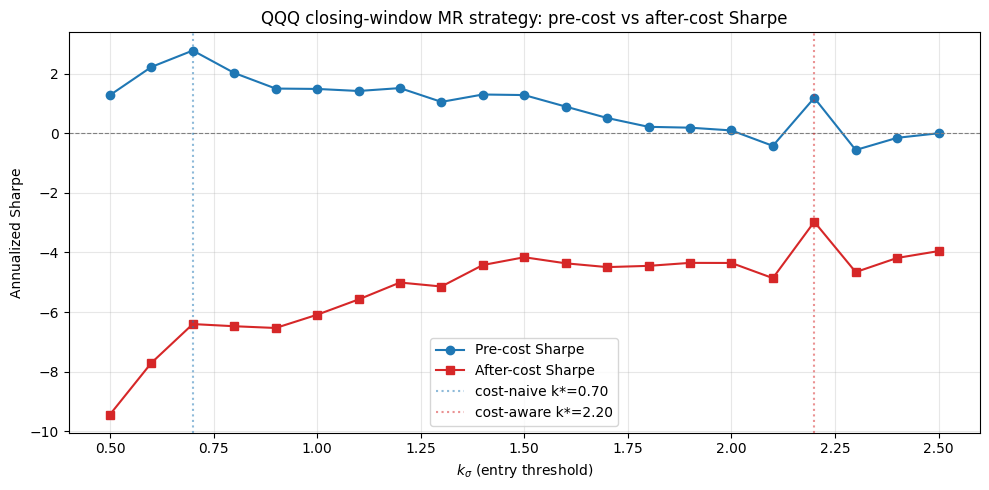

In [11]:
# Plot pre- vs after-cost Sharpe across the k_sigma sweep
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sweep["k"], sweep["S_pre"], "o-", label="Pre-cost Sharpe",
        color="tab:blue")
ax.plot(sweep["k"], sweep["S_post"], "s-", label="After-cost Sharpe",
        color="tab:red")
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(best_pre["k"], color="tab:blue", linestyle=":", alpha=0.5,
           label=f"cost-naive k*={best_pre['k']:.2f}")
ax.axvline(best_post["k"], color="tab:red", linestyle=":", alpha=0.5,
           label=f"cost-aware k*={best_post['k']:.2f}")
ax.set_xlabel(r"$k_\sigma$ (entry threshold)")
ax.set_ylabel("Annualized Sharpe")
ax.set_title("QQQ closing-window MR strategy: pre-cost vs after-cost Sharpe")
ax.legend(loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Cost-naive k\* = 0.70 (S_pre = +2.77); cost-aware k\* = 2.20 (S_post = −3.34).**

Two facts to absorb.

1. **The cost-naive optimum (k=0.70) gives the worst after-cost performance** (S_post = −7.20). Low thresholds maximize trade count, and trade count is what costs are levied against. Each marginal trade costs the strategy ~1.6 bp; trades whose pre-cost mean is below that are pure losers post-cost.
2. **Even the cost-aware optimum is negative** — S_post = −3.34, achieved by trading only the most extreme moves (200 trades over the year instead of 892). Raising the threshold concentrates the per-trade edge (k=2.2 has per-trade mean ~0.46 bp vs k=1.0's 0.32 bp), but not enough to clear the 1.6 bp cost wedge.

The cost-aware optimum is "least bad," not "good." The strategy is unprofitable at every threshold.

In [12]:
# Capacity at the cost-aware k* as well
tr_k_star = event_driven_backtest(rth, k_sigma=float(best_post["k"]))
mu_k_star = tr_k_star["pnl_log"].mean() * 1e4
Q_star_kstar, budget_kstar = capacity(mu_k_star, half_spread_bp,
                                       commission_per_leg_bp, sigma_d,
                                       adv_dollars_consolidated)
print(f"At cost-aware k* = {best_post['k']:.2f}:")
print(f"  per-trade mean:        {mu_k_star:+.3f} bp")
print(f"  round-trip explicit:   {2*(half_spread_bp+commission_per_leg_bp):.3f} bp")
print(f"  impact budget:         {budget_kstar:+.3f} bp")
print(f"  capacity Q*:           ${Q_star_kstar:,.0f}")
print()
print("Both capacities are $0 — the explicit cost wedge alone "
      "exceeds the per-trade mean.")


At cost-aware k* = 2.20:
  per-trade mean:        +0.461 bp
  round-trip explicit:   1.592 bp
  impact budget:         -1.131 bp
  capacity Q*:           $0

Both capacities are $0 — the explicit cost wedge alone exceeds the per-trade mean.


## §7 — The deflation arc, closed by reality

We can now stack every Sharpe we've quoted for this strategy in chronological order of "more honest evaluation":

| Stage | Sharpe | What changed |
|---|---|---|
| Ch8 vectorized backtest, no costs | **+2.08** | Overlap + same-bar bug + in-sample |
| Ch9 event-driven, no costs | **+0.80** | Honest mechanics; CI straddles 0 |
| Ch10 trailing-σ, no costs | **+1.64** | Bias-corrected threshold |
| Ch11 train/test OOS, no costs | **+0.46** | 30% held out from parameter selection |
| Ch11 walk-forward OOS, no costs | **+0.88** | Continuous OOS over 10 monthly refits |
| **Ch12 after-cost at cost-aware k\*** | **−3.34** | Spread (0.72bp/leg) + commission (0.07) + impact |
| **Ch12 capacity Q\*** | **$0** | Per-trade mean < explicit cost wedge |

The end-to-end deflation: **+2.08 (cost-free, snooped) → −3.34 (cost-aware honest)**. A reversal — not a reduction — of sign. The strategy isn't "real but weak"; it isn't even a hypothesis worth more data. **It does not exist as a tradable edge.**

This is what an honest pipeline produces. Most candidate strategies fail at the cost step; the surprise would be if this one didn't.

## So what?

Decision rules this chapter unlocks:

1. **Compute Roll's (or Corwin-Schultz) effective half-spread on your data before *anything* else.** If your strategy's per-trade mean is less than 2× the round-trip spread, you don't have a strategy — you have a cost generator. The bar for a 1-min ETF strategy is roughly per-trade-mean > 2 bp; below that, you're trading the spread of your broker against you.
2. **Re-optimize the threshold parameter under after-cost Sharpe.** Cost-aware optima sit at higher thresholds and lower trade counts. The cost-naive optimum is almost always the worst after-cost choice (because it maximizes trade frequency, which is what costs are levied against).
3. **Quote capacity Q\* alongside Sharpe.** A strategy that works at $30k may evaporate by $1M. The capacity equation lets you size the lift to a target dollar PnL: at Q\*, after-cost expectancy is zero; halfway up the curve, after-cost expectancy is half its no-impact maximum. Capacity is the link from "strategy works" to "strategy works at the size I need."
4. **If your impact budget is negative, your strategy is dead at any size.** No clever execution trick rescues a negative budget. The right responses are: find a strategy with larger per-trade mean (different family, different gate, different instrument with a stickier mispricing); reduce trade frequency; switch to a market with lower costs (futures often beat ETFs in bp terms once you account for notional leverage).

What this chapter cannot yet tell you:

- **Whether limit-order execution beats market-order execution by enough to flip the sign.** Posting passively *captures* half-spread instead of paying it — and on this strategy that swing is ~1.4 bp round-trip, larger than the cost wedge. Ch13 (microstructure & execution) covers this: passive vs aggressive, queue position, partial fills, and the strategy's *fill rate* tradeoff.
- **What the actual realized impact looks like in production.** η = 0.1 is an empirical average across liquid US equities; on any given day η can swing 2-3×. Ch13 also addresses fill-quality measurement (TWAP/VWAP slippage, implementation-shortfall framework).
- **Whether the strategy works on other instruments where the cost economics differ.** Exercise 1 below transfers to SPY; Exercise 4 looks at the closing-window Roll's question that motivated this chapter's reframing.

## Key Terms

| Term | Definition |
|---|---|
| Explicit cost | Costs that hit the brokerage statement: commission, exchange/SEC fees, financing. |
| Implicit cost | Costs paid through prices: bid/ask spread (crossed on entry and exit) and slippage / market impact. |
| Half-spread | Half the bid/ask spread; the one-leg cost of crossing the spread once. |
| Roll's estimator | Estimator of half-spread from trade-price returns: s = √(−Cov(r<sub>t</sub>, r<sub>t−1</sub>)). Defined only when lag-1 cov is negative; gives an upper bound on the true spread. |
| Corwin-Schultz estimator | Estimator of spread from two-bar high-low ranges; independent of Roll's. Used as a second-opinion sanity check. |
| Square-root impact law | Empirical regularity that temporary market impact scales as η σ<sub>d</sub> √(Q/ADV); η ≈ 0.1 for liquid US equities. |
| ADV | Average daily volume, typically quoted in dollars; the denominator of the impact equation. Consolidated tape vs IEX-only differ by ~30× on ETFs. |
| Strategy capacity (Q\*) | The trade size at which after-cost expectancy crosses zero. Q\* = ADV·((μ − 2s − 2c)/(2η σ<sub>d</sub>))² when the impact budget is positive; Q\* = 0 otherwise. |
| Cost-aware optimization | Re-tuning strategy parameters with after-cost performance as the objective. Typically yields higher thresholds and lower trade counts than cost-naive optima. |
| Payment for order flow (PFOF) | Broker routes retail order to a wholesale market maker who pays for the flow; enables zero commission but shifts cost into the spread the wholesaler captures. |

## Up next

**Ch13 — Microstructure and execution.** Limit-order books, queue position, passive vs aggressive fills, implementation-shortfall measurement. Ch12 priced cost as a fixed wedge; Ch13 turns cost into a function of *how you execute*. The strategy that fails Ch12 with market orders might survive Ch13 with limit orders — at the price of partial fills and slower execution. Whether that survival is genuine or another cost-shifting illusion is the question.

## Exercises

1. **SPY transfer.** Compute Roll's and Corwin-Schultz half-spreads on SPY 1-min (`../06-bridge-to-intraday/data/spy_1min.parquet`). Then re-run the cost-aware k_σ sweep using SPY's own σ<sub>d</sub>, ADV, and Ch7/Ch11's pipeline. Does SPY's after-cost picture look different from QQQ's? *Hint:* SPY's underlying volatility is slightly lower than QQQ's, so per-trade signal-to-noise is smaller; but spread and commission per leg should be comparable.

2. **Cost-sensitivity heatmap.** Build a heatmap with η ∈ {0.05, 0.1, 0.2, 0.3} along one axis and half-spread ∈ {0.5, 1.0, 1.5} bp along the other. Inside each cell, re-optimize k_σ for after-cost Sharpe and store the maximum. Which combinations of η and spread produce *any* positive after-cost Sharpe at all? *Hint:* the cell at (η=0.05, spread=0.5) is the most favorable; if even that doesn't go positive, the strategy is structurally dead.

3. **Capacity vs k_σ.** Plot Q\* against k_σ for k_σ ∈ {0.5, 1.0, 1.5, 2.0, 2.5}. (Use the consolidated ADV $15B; plot Q\* = 0 wherever the impact budget is negative.) Does the cost-aware k\* coincide with the maximum-capacity k\*? If not, the strategy's "optimal threshold" depends on whether your objective is Sharpe or dollar capacity — name the tradeoff.

4. *(Stretch)* **Roll's on subsamples revisited.** §2 found closing-window Roll's *lower* than midday Roll's. Reproduce that, then form the closing-window vs midday Corwin-Schultz comparison. Does CS agree with Roll's on the direction? If both agree closing-window has lower effective spread, what does that say about Ch7's "closing window has 2× MR" finding — is the extra MR genuine signal or partly mechanical?
